# Pipeline Stage-by-Stage Debugger

A debugging notebook where **each pipeline sub-step gets its own cell** so
we can inspect each intermediate step in isolation — before moving to the next cell. This helps us understand how the method works, how different steps in the process impact the results, and diagnose and resolve any issues.

Every cell calls `inspect()`, which:
1. Runs the same three formal QA checks (`all_nan`, `out_of_range`,
   `sporadic_nan_days`) from `srm.qa_checks` — the same checks a
   `bcsd qa` run applies to a cached artifact.
2. Prints a PASS/FAIL verdict per check.
3. Plots a spatial map (`time=0`) and a domain-mean time series.
4. Registers the computed array in the `STEPS` dict so the cross-stage
   evolution plots at the bottom can iterate over every step.



In [1]:
%load_ext autoreload
%autoreload 2

import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import rasterix  # noqa: F401  # registers .proj/.rio accessors
import xarray as xr
import xarray_regrid  # noqa: F401  # registers .regrid namespace

from srm.bcsd_config import BCSDConfig, PipelineOptions, VariableConfig
from srm.downscaling_utils import (
    calculate_doy_means,
    downscale_from_coarse,
    get_historical_experiment,
    get_obs,
    interpolate_coarse_to_fine_grid,
    interpolate_fine_to_coarse_grid,
    retrend,
    subset_space,
)
from srm.pipeline import BCSDPipeline
from srm.qa_checks import _STATUS_SYMBOL, run_artifact_checks
from srm.validation import CheckStatus

import icechunk
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from srm.lineage import resolve_member_lineage
from srm.utils import open_icechunk

warnings.filterwarnings("ignore", category=FutureWarning)


def _step_title(step: str, width: int = 16) -> str:
    """Wrap a snake_case step name to fit in a narrow subplot title."""
    return textwrap.fill(step.replace("_", " "), width=width)

## Config

**Edit only this cell** between debug runs. Set `SCENARIO = None` to debug
Stage 1 + Stage 2 only; set a scenario string to also exercise Stage 3.

`scratch_dir` and `output_dir` point to a local tmp directory so no debug
writes touch the real S3 cache.


In [2]:
# ── Edit these values ──────────────────────────────────────────────────────────
GCM = "CESM2-WACCM"# "MIROC-ES2H"
VARIABLE = "pr"
ENSEMBLE_MEMBER = "003" #"r02"  # CESM2-WACCM SSP245/G6-1.5K uses numeric IDs; "001" → hist r1i1p1f1
SCENARIO = "SSP245"  # None → Stage 1+2 only; set e.g. "SSP245" / "G6-1.5K" to also exercise Stage 3

# Southern Africa including high spot in Angola.
# (lat_min, lat_max, lon_min, lon_max)
SUBSET_BOUNDS = (-15,5, -90, -70) # saved this with nonparametric_hybrid_2sided
# SUBSET_BOUNDS = (-50,70, -180, -180) # <--- do this with QDM!
# SUBSET_BOUNDS = (-26, -23, -70, -67) # includes good weibull pixel
# SUBSET_BOUNDS = (0, 5, -79, -74) # includes good gumbel pixel
# SUBSET_BOUNDS = None#(-35, -22, 16, 33)# (-67, 67, -180, 180)
# SUBSET_BOUNDS = (-30, -25, 16, 22)# (-67, 67, -180, 180)

# Override rsds's default debias_approach ("nonparametric_hybrid_2sided") with
# plain "nonparametric" — keeps every other rsds setting (downscaling_method,
# downscaling_clim_method, ...) from VariableConfig.for_variable() as-is.
debiasing_approach = "qdm"# "qdm" #"nonparametric_hybrid_2sided"# "nonparametric"
variable_config = VariableConfig.for_variable(VARIABLE).model_copy(
    update={"debias_approach": debiasing_approach}
)
# ──────────────────────────────────────────────────────────────────────────────

config = BCSDConfig(
    gcm=GCM,
    variable=VARIABLE,
    ensemble_member=ENSEMBLE_MEMBER,
    scenario=SCENARIO,
    # predict_period_start must equal the scenario data start (2015 for SSP245)
    # so stitch_historical_scenario produces a gap-free 1978–end timeseries.
    predict_period_start=2015 if SCENARIO else None,
    predict_period_end=2099 if SCENARIO else None,
    subset_bounds=SUBSET_BOUNDS,
    variable_config=variable_config,
)
options = PipelineOptions(
    scratch_dir="/tmp/bcsd-debug/scratch/",  # local — never touches S3
    output_dir="/tmp/bcsd-debug/output/",
    branch="debug",
    environment="debug",
)
pipeline = BCSDPipeline(config, options)
print(f"Run: {config.run_id}")
print(f"Subset bounds: {config.subset_bounds}")
print(f"Scenario: {config.scenario!r}")
print(f"Predict period: {config.predict_period_start}–{config.predict_period_end}")
print(f"Debias approach: {config.variable_config.debias_approach}")

Run: CESM2-WACCM_pr_003_SSP245_subset
Subset bounds: (-15.0, 5.0, -90.0, -70.0)
Scenario: 'SSP245'
Predict period: 2015–2099
Debias approach: qdm


In [3]:
inspect_variables=False

## Inspection helper

`inspect(da, stage)` is called after every sub-step. It:
- `.compute()`s the DataArray (fine for the small subset region)
- Runs `run_artifact_checks()` (skipped for arrays with a `dayofyear` dim
  instead of a `time` dim, since those lack the time axis the checks need)
- Prints a PASS/FAIL line per check with detail for any non-PASS result
- Plots spatial map + domain-mean series
- Registers `da` in `STEPS` and its NaN fraction in `STEP_NAN_FRACTIONS`


In [4]:
STEPS: dict[str, xr.DataArray] = {}  # ordered; keys = step labels
STEP_NAN_FRACTIONS: dict[str, float] = {}  # per-step nan_fraction for bar chart


def inspect(
    da: xr.DataArray,
    stage: str,
    *,
    skip_qa: bool = False,
) -> xr.DataArray:
    """Compute, QA-check, plot, and register a pipeline intermediate."""
    print(f"\n{'=' * 60}")
    print(f"  {stage}")
    print(f"{'=' * 60}")

    da = da.compute()
    STEPS[stage] = da

    has_time = "time" in da.dims
    has_doy = "dayofyear" in da.dims

    # ── QA checks ─────────────────────────────────────────────────────────────
    if not skip_qa and has_time:
        results = run_artifact_checks(
            da,
            gcm=config.gcm,
            variable=config.variable,
            ensemble_member=config.ensemble_member,
            scenario=config.scenario,
            stage=stage,
        )
        STEP_NAN_FRACTIONS[stage] = results["all_nan"].nan_fraction
        for check_name, result in results.items():
            sym = _STATUS_SYMBOL[result.status]
            line = f"  {sym} {check_name}: {result.status.upper()}"
            if result.message:
                line += f" — {result.message}"
            print(line)
            if result.status not in (CheckStatus.PASS, CheckStatus.SKIP) and result.detail:
                for k, v in result.detail.items():
                    print(f"        {k}: {v}")
    elif has_doy:
        print("  (QA checks skipped — dayofyear dimension, no time axis)")
    else:
        print("  (QA checks skipped)")

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"  shape: {dict(da.sizes)}")
    if has_time or has_doy:
        nan_frac = float(np.isnan(da.values).mean())
        print(f"  NaN:   {nan_frac:.4f} ({nan_frac * 100:.2f}%)")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(stage, fontsize=12, fontweight="bold")
    try:
        if has_time:
            da.isel(time=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("time=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean time series")
        elif has_doy:
            da.isel(dayofyear=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("dayofyear=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean DOY series")
        else:
            for ax in axes:
                ax.text(0.5, 0.5, "no time/dayofyear dim", transform=ax.transAxes, ha="center")
    except Exception as exc:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                f"plot error:\n{exc}",
                transform=ax.transAxes,
                ha="center",
                fontsize=8,
                wrap=True,
            )
    plt.tight_layout()
    plt.show()
    return da

## ERA5-relative exceedance helpers

Adapted from `synced/notebooks/check_reasonable_ranges.ipynb`. Unlike the
global physical-bounds check in `qa_checks.py`, these compare the downscaled
output against ERA5's **per-pixel** historical min/max — so a value that is
physically plausible globally but implausible at that specific location is
still flagged.

`obs_fine_s2` / `obs_fine_s3` (already in memory) serve as the ERA5
reference, so no extra S3 reads are needed.


In [5]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    _HAS_CARTOPY = True
except ImportError:
    _HAS_CARTOPY = False

_MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Grey for zero exceedances; continuous Reds for nonzero — makes clean regions
# immediately obvious without needing a separate mask plot.
_EXCEEDANCE_CMAP = plt.cm.Reds.copy()
_EXCEEDANCE_CMAP.set_under("lightgrey")


def _era5_threshold(obs_fine: xr.DataArray, direction: str, period: str) -> xr.DataArray:
    """Per-pixel ERA5 min/max from obs_fine already in memory.

    Parameters
    ----------
    obs_fine : already-computed fine-grid ERA5 DataArray
    direction : "gt" → max threshold; "lt" → min threshold
    period    : "annual" or "monthly"
    """
    fn = "max" if direction == "gt" else "min"
    if period == "annual":
        return getattr(obs_fine, fn)("time").compute()
    return getattr(obs_fine.groupby("time.month"), fn)("time").compute()


def _count_exceedances(
    da: xr.DataArray,
    threshold: xr.DataArray,
    direction: str,
    period: str,
) -> xr.DataArray:
    """Number of time steps per pixel that exceed the given threshold."""
    if period == "annual":
        mask = da > threshold if direction == "gt" else da < threshold
        return mask.sum("time").compute()
    counts = []
    for m, group in da.groupby("time.month"):
        exceeded = (
            group > threshold.sel(month=m) if direction == "gt" else group < threshold.sel(month=m)
        )
        counts.append(exceeded.sum("time").expand_dims(month=[m]))
    return xr.concat(counts, dim="month").compute()


def _plot_map(da, ax, title, **kw):
    """Single-panel map with optional cartopy coastlines."""
    proj_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    da.plot(ax=ax, **kw, **proj_kw)
    if _HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=9)


def plot_time_extremes(da: xr.DataArray, label: str) -> None:
    """2×2 grid: time-min and time-max with default and robust color scaling."""
    proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), subplot_kw=proj)
    fig.suptitle(f"{label} — time extremes", fontweight="bold")
    _plot_map(da.min("time"), axes[0, 0], "time min")
    _plot_map(da.max("time"), axes[0, 1], "time max")
    _plot_map(da.min("time"), axes[1, 0], "time min (robust)", robust=True)
    _plot_map(da.max("time"), axes[1, 1], "time max (robust)", robust=True)
    plt.tight_layout()
    plt.show()


def check_era5_exceedances(
    da: xr.DataArray,
    obs_fine: xr.DataArray,
    label: str,
    period: str = "annual",
) -> None:
    """Flag pixels where da ever exceeds ERA5's per-pixel historical min/max.

    Prints pixel counts and plots exceedance maps (grey = clean, Reds = flagged).
    Set period="monthly" for a 3×4 faceted map — slower but more granular.
    """
    print(f"\n── ERA5-relative exceedance: {label} ({period}) ──")
    n_pixels = int(da.isel(time=0).size)

    for direction, label_suffix in [("gt", "days > ERA5 max"), ("lt", "days < ERA5 min")]:
        thresh = _era5_threshold(obs_fine, direction, period)
        count = _count_exceedances(da, thresh, direction, period)

        n_flagged = int((count > 0).sum().values)
        pct = n_flagged / n_pixels
        sym = "✗" if n_flagged > 0 else "✓"
        print(f"  {sym} {label_suffix}: {n_flagged}/{n_pixels} pixels flagged ({pct:.1%})")

        proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
        if period == "annual":
            fig, ax = plt.subplots(figsize=(8, 5), subplot_kw=proj)
            _plot_map(count, ax, f"{label}\n{label_suffix}", cmap=_EXCEEDANCE_CMAP, vmin=0.5)
            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(3, 4, figsize=(20, 10), subplot_kw=proj)
            fig.suptitle(f"{label}\n{label_suffix}", fontsize=11)
            for i, ax in enumerate(axes.flat):
                _plot_map(
                    count.sel(month=i + 1),
                    ax,
                    _MONTH_NAMES[i],
                    cmap=_EXCEEDANCE_CMAP,
                    vmin=0.5,
                )
            plt.tight_layout()
            plt.show()

## Stage 1 — `prepare_observations`

Replicates the internals of `BCSDPipeline.prepare_observations` step by step. The final cell writes the result to the debug cache so Stage 2's `_load_gcm_obs()` can find it.


In [6]:
# ── obs_fine: fine-resolution ERA5 observations ───────────────────────────────
obs_fine = get_obs(var=config.variable, dataset_name=config.obs_dataset)
obs_fine = obs_fine.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    obs_fine = subset_space(obs_fine, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max))
train_slice = slice(str(config.train_period_start), str(config.train_period_end))
obs_fine = obs_fine.sel(time=train_slice)
if inspect_variables:
    obs_fine = inspect(obs_fine, "obs_fine")

In [7]:
# ── model_grid: GCM historical run (used only as a coarse grid template) ──────
model_grid = get_historical_experiment(
    gcm=config.gcm, member=pipeline._hist_member, var=config.variable
)
model_grid = model_grid.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    model_grid = subset_space(
        model_grid, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max)
    )
model_grid = model_grid.sel(time=train_slice)

In [8]:
# ── obs_coarse: ERA5 obs regridded to the GCM coarse grid ─────────────────────
obs_coarse_stage1 = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=model_grid
)
if inspect_variables:
    obs_coarse_stage1 = inspect(obs_coarse_stage1, "obs_coarse_stage1")

In [9]:
%%time
# ── Write to debug cache so Stage 2 _load_gcm_obs() can find obs_regridded ───
# This is equivalent to running prepare_observations() but on the debug branch.
# force=True overwrites any previous debug-branch artifact.
print("Writing obs_coarse to debug cache via prepare_observations(force=True) ...")
prepare_obs_path = pipeline.prepare_observations(force=True)
print(f"  → {prepare_obs_path}")

Writing obs_coarse to debug cache via prepare_observations(force=True) ...


  2026-08-14T20:23:51.069387Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-08-14T20:23:51.441404Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



  → /tmp/bcsd-debug/scratch/debug/CESM2-WACCM-ERA5-lat-15.0to5.0_lon-90.0to-70.0.icechunk
CPU times: user 2min 55s, sys: 1min 1s, total: 3min 57s
Wall time: 35.6 s


## Stage 2 — `fit_historical` (debiasing + spatial downscaling)


In [10]:
%%time
# ── _load_gcm_obs: reload from debug cache + load obs_fine, model_hist ────────
obs_coarse, obs_fine_s2, model_hist = pipeline._load_gcm_obs()
if inspect_variables:
    obs_coarse = inspect(obs_coarse, "obs_coarse")
    obs_fine_s2 = inspect(obs_fine_s2, "obs_fine_s2")
    model_hist = inspect(model_hist, "model_hist")

  2026-08-14T20:24:26.645927Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-08-14T20:24:26.646920Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



CPU times: user 91.5 ms, sys: 10.5 ms, total: 102 ms
Wall time: 368 ms


In [11]:
%%time
# ── _apply_bias_correction: ibicus QuantileMapping on historical period ────────
# It calls .values / .load() internally so it is always eager; runtime ~ 1–5 min
# on the South Africa subset.
debiased_coarse = pipeline._apply_bias_correction(obs_coarse, model_hist)
if inspect_variables:
    debiased_coarse = inspect(debiased_coarse, "debiased_coarse")

CPU times: user 5.92 s, sys: 7.52 s, total: 13.4 s
Wall time: 2min 6s


QDM takes:
two-sided-hybrid takes:

## Stage 3 — `transform_scenario`

Cells below run only when `SCENARIO` is set in the config cell. Run
`pipeline.fit_historical(force=True)` (the optional cell at the end of
Stage 2) before executing these cells, so the historical artifact exists in
the debug cache and `_load_scenario_data()` can validate its dependency.


In [12]:
if config.scenario is None:
    raise RuntimeError(
        "SCENARIO is None. Set SCENARIO in the config cell and re-run "
        "from the top before executing Stage 3 cells."
    )

In [13]:
%%time
# ── _load_scenario_data ────────────────────────────────────────────────────────
(
    obs_coarse_s3,
    obs_fine_s3,
    model_hist_s3,
    model_scenario,
    ssp_timeseries,
) = pipeline._load_scenario_data()

if inspect_variables:
    obs_coarse_s3 = inspect(obs_coarse_s3, "obs_coarse_s3")
    obs_fine_s3 = inspect(obs_fine_s3, "obs_fine_s3")
    model_hist_s3 = inspect(model_hist_s3, "model_hist_s3")
    model_scenario = inspect(model_scenario, "model_scenario")
if ssp_timeseries is not None:
    ssp_timeseries = inspect(ssp_timeseries, "ssp_timeseries")

  2026-08-14T20:26:33.204376Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-08-14T20:26:33.205441Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-08-14T20:26:33.205498Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



CPU times: user 108 ms, sys: 13.9 ms, total: 122 ms
Wall time: 414 ms


In [14]:
# ── _detrend_scenario ──────────────────────────────────────────────────────────
scenario_detrended, scenario_trend = pipeline._detrend_scenario(
    model_hist_s3, model_scenario, ssp_timeseries
)

In [15]:
%%time
# ── _apply_bias_correction_scenario ───────────────────────────────────────────
scenario_debiased = pipeline._apply_bias_correction_scenario(
    obs_coarse_s3, model_hist_s3, scenario_detrended
)
if inspect_variables:
    scenario_debiased = inspect(scenario_debiased, "scenario_debiased")

CPU times: user 18.6 s, sys: 13.3 s, total: 31.9 s
Wall time: 5min 51s


In [16]:
if config.subset_bounds is None:
    subset_string = 'GLOBAL'
else:
    subset_string = str(SUBSET_BOUNDS).replace(" ","_").replace("(", "").replace(")","").replace(",","")
debiased_coarse.to_dataset(name='pr').to_zarr(f's3://carbonplan-scratch/srm/debiased_coarse-{VARIABLE}-{debiasing_approach}_{subset_string}.zarr', mode='w')
scenario_debiased.to_dataset(name='pr').to_zarr(f's3://carbonplan-scratch/srm/scenario_debiased-{VARIABLE}-{debiasing_approach}_{subset_string}.zarr', mode='w')

/opt/coiled/env/lib/python3.13/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


# QDM vs two-sided

In [25]:
# load in prod run

In [17]:
# --- Run identity (from configs/production/cesm2-waccm/cesm2-waccm-ssp245-std.yaml) ---
gcm = "CESM2-WACCM"
obs_dataset = "ERA5"
scenario = "ssp245"  # icechunk group name (SCENARIO_TO_GROUP["SSP245"])
ensemble_member = "003"
var = "pr"

# --- Data source ---
path_output = (
    "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling"
    f"/output/production/{gcm}-{obs_dataset}-global.icechunk"
)
branch = "v0.13.0"  # icechunk branch; must match a real branch (checked below)

In [18]:
bucket, prefix = path_output.replace("s3://", "").rstrip("/").split("/", 1)
repo = icechunk.Repository.open(
    icechunk.s3_storage(bucket=bucket, prefix=prefix, region="us-west-2")
)
print("Available branches:", repo.list_branches())
assert branch in repo.list_branches(), f"branch {branch!r} not found"


Available branches: {'v0.13.0', 'main', 'v0.12.0'}


In [19]:
# Historical and scenario debiased_coarse are separate runs keyed by different
# ensemble-member IDs; resolve the historical member from the lineage table
# rather than hardcoding it.
hist_member = resolve_member_lineage(
    gcm=gcm, scenario="SSP245", ensemble_member=ensemble_member, variable=var
).historical
print("historical member:", hist_member)

historical member: r3i1p1f1


In [20]:
prod_debiased_coarse_hist = open_icechunk(
    path=path_output,
    branch=branch,
    group=f"debiased_coarse/historical/{var}/{hist_member}",
)[var]

prod_debiased_coarse_ssp245 = open_icechunk(
    path=path_output,
    branch=branch,
    group=f"debiased_coarse/{scenario}/{var}/{ensemble_member}",
)[var]

print(prod_debiased_coarse_hist.time.min().values, "-", prod_debiased_coarse_hist.time.max().values)
print(prod_debiased_coarse_ssp245.time.min().values, "-", prod_debiased_coarse_ssp245.time.max().values)

1978-01-01T00:00:00.000000000 - 2014-12-31T00:00:00.000000000
2015-01-01T00:00:00.000000000 - 2099-12-31T00:00:00.000000000


In [21]:
prod_debiased_coarse = xr.concat(
    [prod_debiased_coarse_hist, prod_debiased_coarse_ssp245], dim="time"
).sortby("time")
prod_debiased_coarse

<xarray.DataArray 'pr' (time: 44560, lat: 192, lon: 288)> Size: 10GB
dask.array<getitem, shape=(44560, 192, 288), dtype=float32, chunksize=(8000, 8, 16), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 356kB 1978-01-01 1978-01-02 ... 2099-12-31
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8

In [31]:
ds_dict= {}
qdm_hist= xr.open_zarr(f's3://carbonplan-scratch/srm/debiased_coarse-{VARIABLE}-qdm_{subset_string}.zarr')
qdm_ssp245 = xr.open_zarr(f's3://carbonplan-scratch/srm/scenario_debiased-{VARIABLE}-qdm_{subset_string}.zarr')
ds_dict['qdm'] = xr.concat([qdm_hist, qdm_ssp245], dim='time')
ds_dict['prod'] = xr.concat([prod_debiased_coarse_hist, prod_debiased_coarse_ssp245], dim="time").sel(lat=slice(ds_dict['qdm'].lat.min(), ds_dict['qdm'].lat.max()),
                                                                                                      lon=slice(ds_dict['qdm'].lon.min(), ds_dict['qdm'].lon.max()))

In [34]:
# ── 2. Max, mean, and std of the difference (nonparametric − hybrid_2sided) ───
def diff_max(a, b):
    return (a - b).max("time")

def diff_min(a, b):
    return (a - b).min("time")

def diff_mean(a, b):
    return (a - b).mean("time")


def diff_std(a, b):
    return (a - b).std("time")

In [35]:
# difference in historic

In [47]:
FUTURE_PERIOD = slice('2030', '2060')
HISTORICAL_PERIOD = slice('1985', '2014')

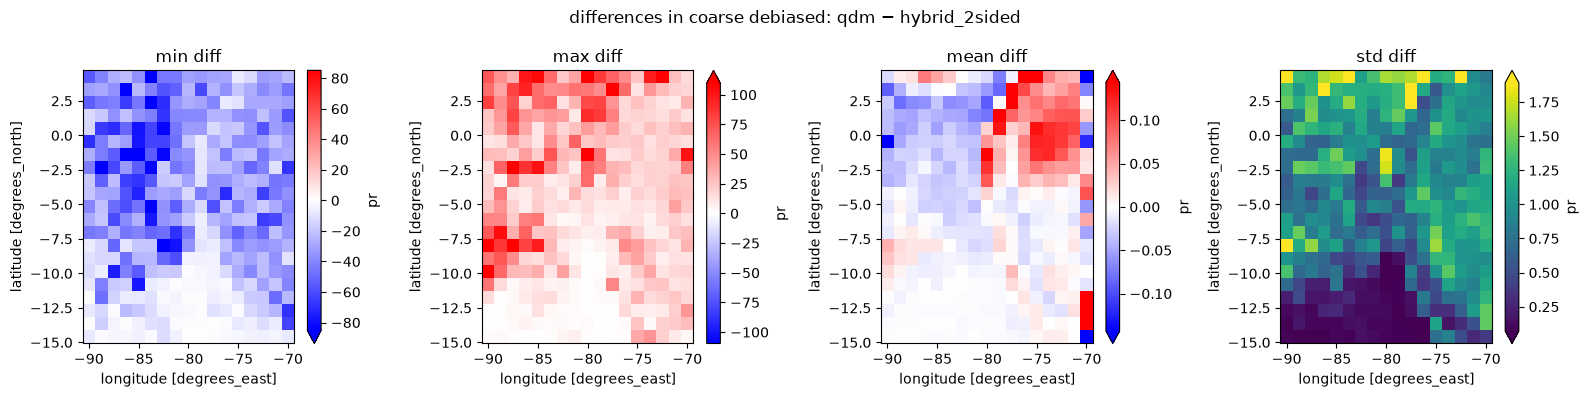

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
time_period = HISTORICAL_PERIOD
prod = ds_dict['prod'].sel(time=time_period) * 86400
qdm = ds_dict['qdm'].sel(time=time_period).pr * 86400
robust=True
diff_min(qdm, prod).plot(ax=axes[0], robust=robust, cmap="bwr", center=0)
diff_max(qdm, prod).plot(ax=axes[1], robust=robust, cmap="bwr", center=0)
diff_mean(qdm, prod).plot(ax=axes[2], robust=robust, cmap="bwr", center=0)
diff_std(qdm, prod).plot(ax=axes[3], robust=robust, cmap="viridis")
for ax, title in zip(axes, ["min diff", "max diff", "mean diff", "std diff"]):
    ax.set_title(title)
fig.suptitle("differences in coarse debiased: qdm − hybrid_2sided")
plt.tight_layout()
plt.show()

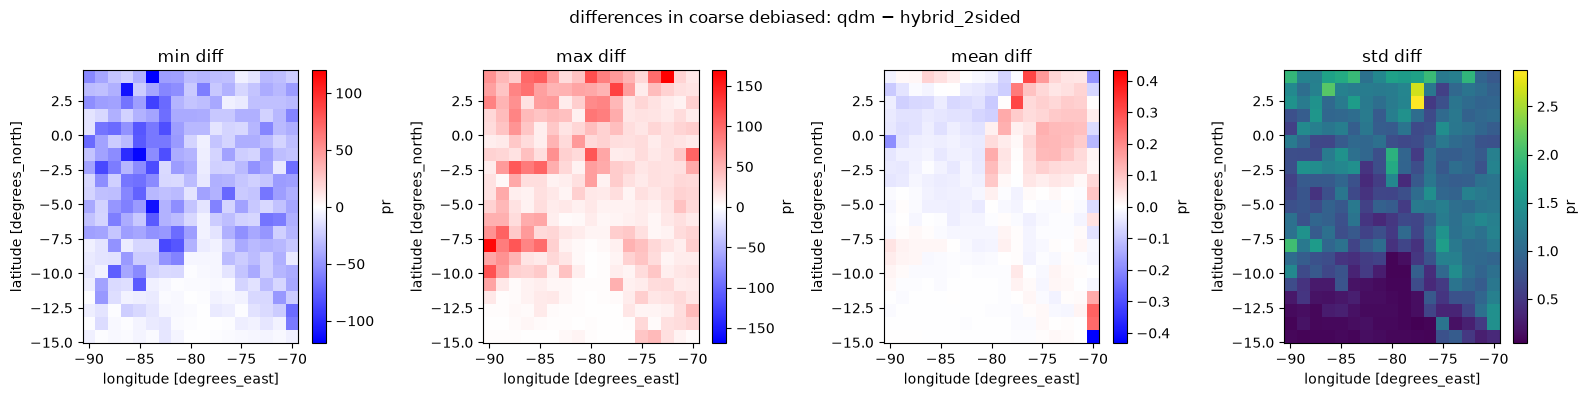

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
time_period = HISTORICAL_PERIOD
prod = ds_dict['prod'].sel(time=time_period) * 86400
qdm = ds_dict['qdm'].sel(time=time_period).pr * 86400
robust=False
diff_min(qdm, prod).plot(ax=axes[0], robust=robust, cmap="bwr", center=0)
diff_max(qdm, prod).plot(ax=axes[1], robust=robust, cmap="bwr", center=0)
diff_mean(qdm, prod).plot(ax=axes[2], robust=robust, cmap="bwr", center=0)
diff_std(qdm, prod).plot(ax=axes[3], robust=robust, cmap="viridis")
for ax, title in zip(axes, ["min diff", "max diff", "mean diff", "std diff"]):
    ax.set_title(title)
fig.suptitle("differences in coarse debiased: qdm − hybrid_2sided")
plt.tight_layout()
plt.show()

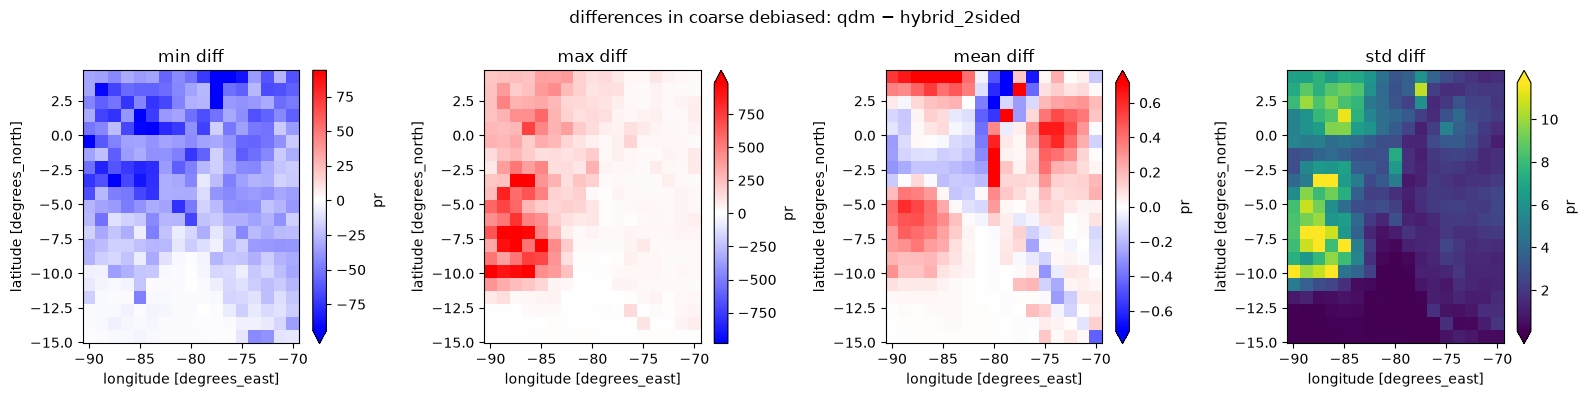

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
time_period = FUTURE_PERIOD
prod = ds_dict['prod'].sel(time=time_period) * 86400
qdm = ds_dict['qdm'].sel(time=time_period).pr * 86400
robust=True
diff_min(qdm, prod).plot(ax=axes[0], robust=robust, cmap="bwr", center=0)
diff_max(qdm, prod).plot(ax=axes[1], robust=robust, cmap="bwr", center=0)
diff_mean(qdm, prod).plot(ax=axes[2], robust=robust, cmap="bwr", center=0)
diff_std(qdm, prod).plot(ax=axes[3], robust=robust, cmap="viridis")
for ax, title in zip(axes, ["min diff", "max diff", "mean diff", "std diff"]):
    ax.set_title(title)
fig.suptitle("differences in coarse debiased: qdm − hybrid_2sided")
plt.tight_layout()
plt.show()

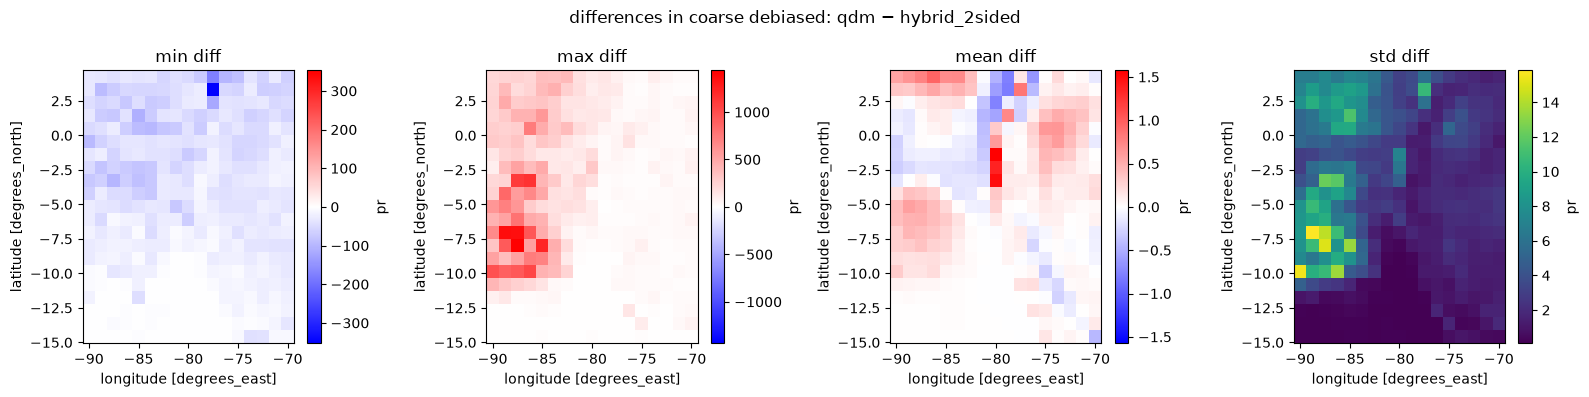

In [52]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
time_period = FUTURE_PERIOD
prod = ds_dict['prod'].sel(time=time_period) * 86400
qdm = ds_dict['qdm'].sel(time=time_period).pr * 86400
robust=False
diff_min(qdm, prod).plot(ax=axes[0], robust=robust, cmap="bwr", center=0)
diff_max(qdm, prod).plot(ax=axes[1], robust=robust, cmap="bwr", center=0)
diff_mean(qdm, prod).plot(ax=axes[2], robust=robust, cmap="bwr", center=0)
diff_std(qdm, prod).plot(ax=axes[3], robust=robust, cmap="viridis")
for ax, title in zip(axes, ["min diff", "max diff", "mean diff", "std diff"]):
    ax.set_title(title)
fig.suptitle("differences in coarse debiased: qdm − hybrid_2sided")
plt.tight_layout()
plt.show()

In [53]:
# ── 3. Climate-change delta (2070–2099 mean − historical mean) per approach ───
# debiased_coarse (Stage 2) is reused as "historical" for both approaches: Stage 2's
# _apply_bias_correction always collapses nonparametric_hybrid* to plain nonparametric
# (modeled historical never falls outside its own range), so it's approach-invariant.
assert ds_dict['prod']["time"].max().values >= np.datetime64(f"{FUTURE_PERIOD.stop}-12-31"), (
    f"scenario data only runs through {nonparametric['time'].max().values} — extend "
    "predict_period_end past 2099 in the config cell, rerun Stage 3, and re-save/re-load "
    "ds_dict before this cell has data for 2070-2099."
)

prod = ds_dict['prod'] * 86400
qdm = ds_dict['qdm'].pr * 86400
raw = xr.concat([model_hist, model_scenario], dim='time') * 86400

In [56]:
def cc_delta(da, metric='mean'):
    """(future - historical) delta, plus the historical stat it was built from.

    Both are returned (and computed only once) because the relative/absolute
    panels both need them: absolute is just the delta; relative divides the
    same delta by the same historical stat. Callers no longer redo the
    future/historical reduction per method the way a method='absolute' /
    method='relative' pair of calls used to.
    """
    historical_period = slice("1985", "2014")
    future_period = slice("2030", "2059")
    if metric == 'mean':
        hist_stat = da.sel(time=historical_period).mean("time")
        fut_stat = da.sel(time=future_period).mean("time")
    elif metric == '99p':
        hist_stat = da.sel(time=historical_period).quantile(0.99, dim="time")
        fut_stat = da.sel(time=future_period).quantile(0.99, dim="time")
    return (fut_stat - hist_stat).compute(), hist_stat.compute()


def relative_delta(absolute_delta, hist_stat):
    return absolute_delta / hist_stat * 100

In [57]:
plot_dict = {'absolute': {}, 'relative': {}}
for metric in ['mean', '99p']:
    print(metric)

    # Each pair is computed once here and reused below for both the absolute
    # panel and (via relative_delta) the relative panel.
    delta_raw, hist_raw = cc_delta(raw, metric=metric)
    delta_prod, hist_prod = cc_delta(prod, metric=metric)
    delta_qdm, hist_qdm = cc_delta(qdm, metric=metric)

    prod_minus_raw = delta_prod - delta_raw
    qdm_minus_raw = delta_qdm - delta_raw
    plot_dict['absolute'][metric] = {
        "Δ raw": [delta_raw, (0, 0)],
        "Δ prod": [delta_prod, (0, 1)],
        "Δ qdm": [delta_qdm, (0, 2)],
        "Δ prod - Δ raw": [prod_minus_raw, (1, 1)],
        "Δ qdm - Δ raw": [qdm_minus_raw, (1, 2)],
        "difference of deltas (qdm - prod)": [qdm_minus_raw - prod_minus_raw, (1, 3)],
    }

    rel_raw = relative_delta(delta_raw, hist_raw)
    rel_prod = relative_delta(delta_prod, hist_prod)
    rel_qdm = relative_delta(delta_qdm, hist_qdm)
    rel_prod_minus_raw = rel_prod - rel_raw
    rel_qdm_minus_raw = rel_qdm - rel_raw
    plot_dict['relative'][metric] = {
        "Δ raw": [rel_raw, (0, 0)],
        "Δ prod": [rel_prod, (0, 1)],
        "Δ qdm": [rel_qdm, (0, 2)],
        "Δ prod - Δ raw": [rel_prod_minus_raw, (1, 1)],
        "Δ qdm - Δ raw": [rel_qdm_minus_raw, (1, 2)],
        "difference of deltas (qdm - prod)": [rel_qdm_minus_raw - rel_prod_minus_raw, (1, 3)],
    }

mean
99p


In [58]:
var_lims_dict = {}
var_lims_dict["absolute"] = {
    "mean": {"Δ raw": (-3, 3),
             "Δ prod": (-3, 3),
             "Δ qdm": (-3, 3),
             "Δ prod - Δ raw": (-3, 3),
             "Δ qdm - Δ raw": (-3, 3),
             "difference of deltas (qdm - prod)": (-1, 1)},
    # 99p shifts far more than the mean does, so it gets its own (larger) bounds.
    "99p": {"Δ raw": (-(10**2), 10**2),
            "Δ prod": (-(10**2), 10**2),
            "Δ qdm": (-(10**2), 10**2),
            "Δ prod - Δ raw": (-(10**2), 10**2),
            "Δ qdm - Δ raw": (-(10**2), 10**2),
            "difference of deltas (qdm - prod)": (-30, 30)},
}
var_lims_dict["relative"] = {
    "mean": {"Δ raw": (-100, 100),
             "Δ prod": (-100, 100),
             "Δ qdm": (-100, 100),
             "difference of deltas (qdm - prod)": (-100, 100)},
    "99p": {"Δ raw": (-100, 100),
            "Δ prod": (-100, 100),
            "Δ qdm": (-100, 100),
            "difference of deltas (qdm - prod)": (-100, 100)},
}

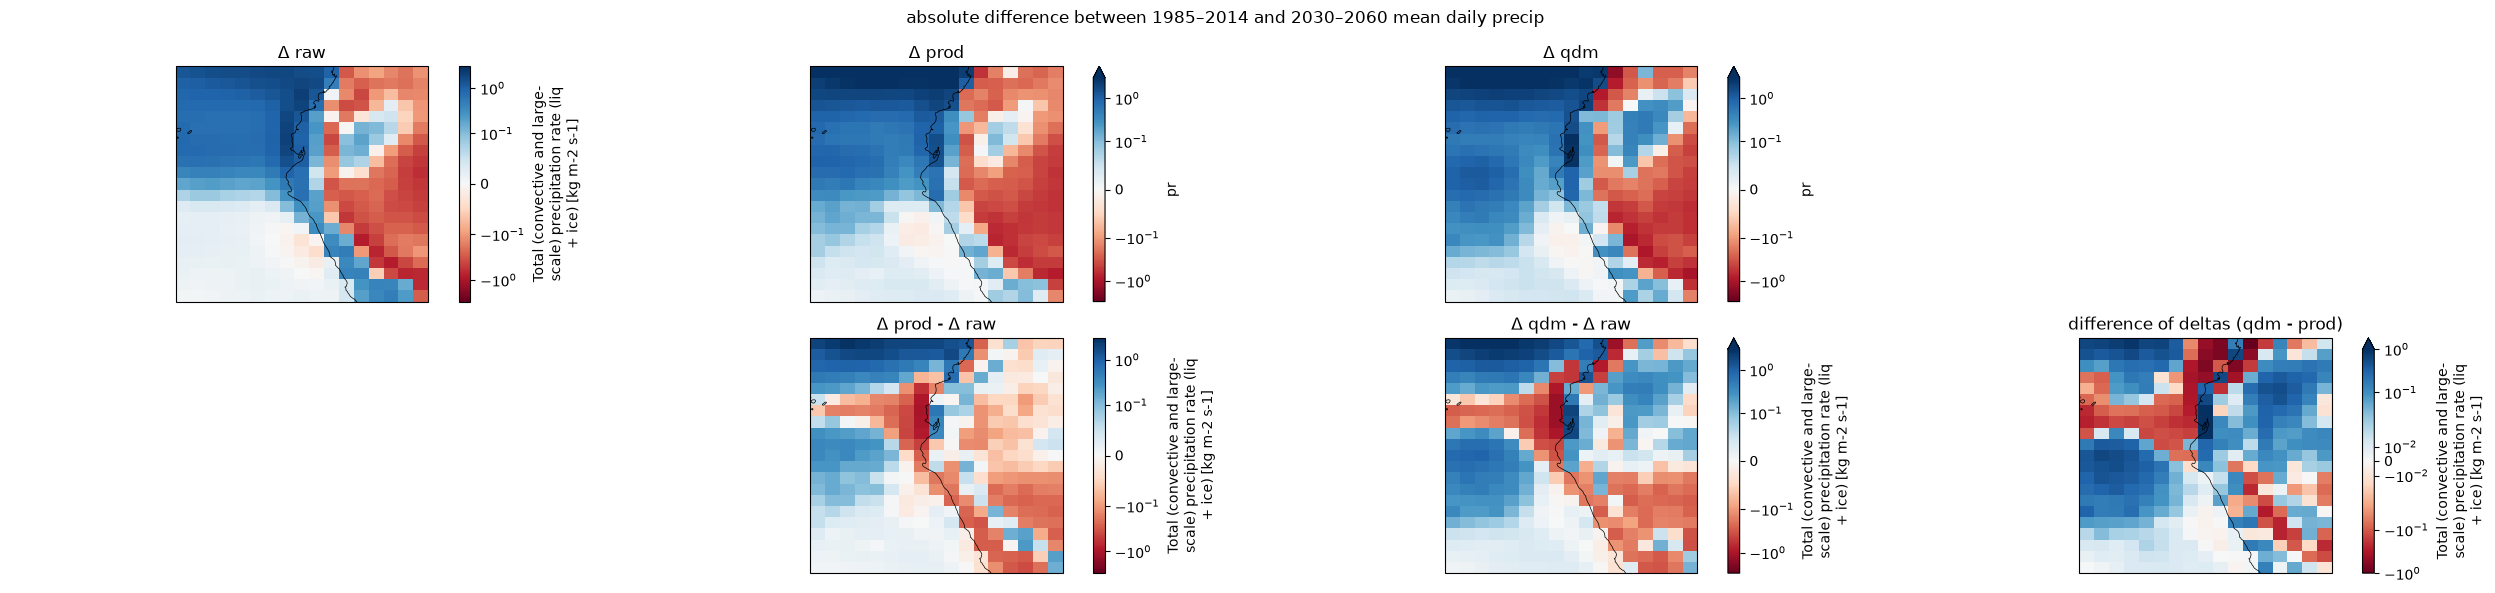

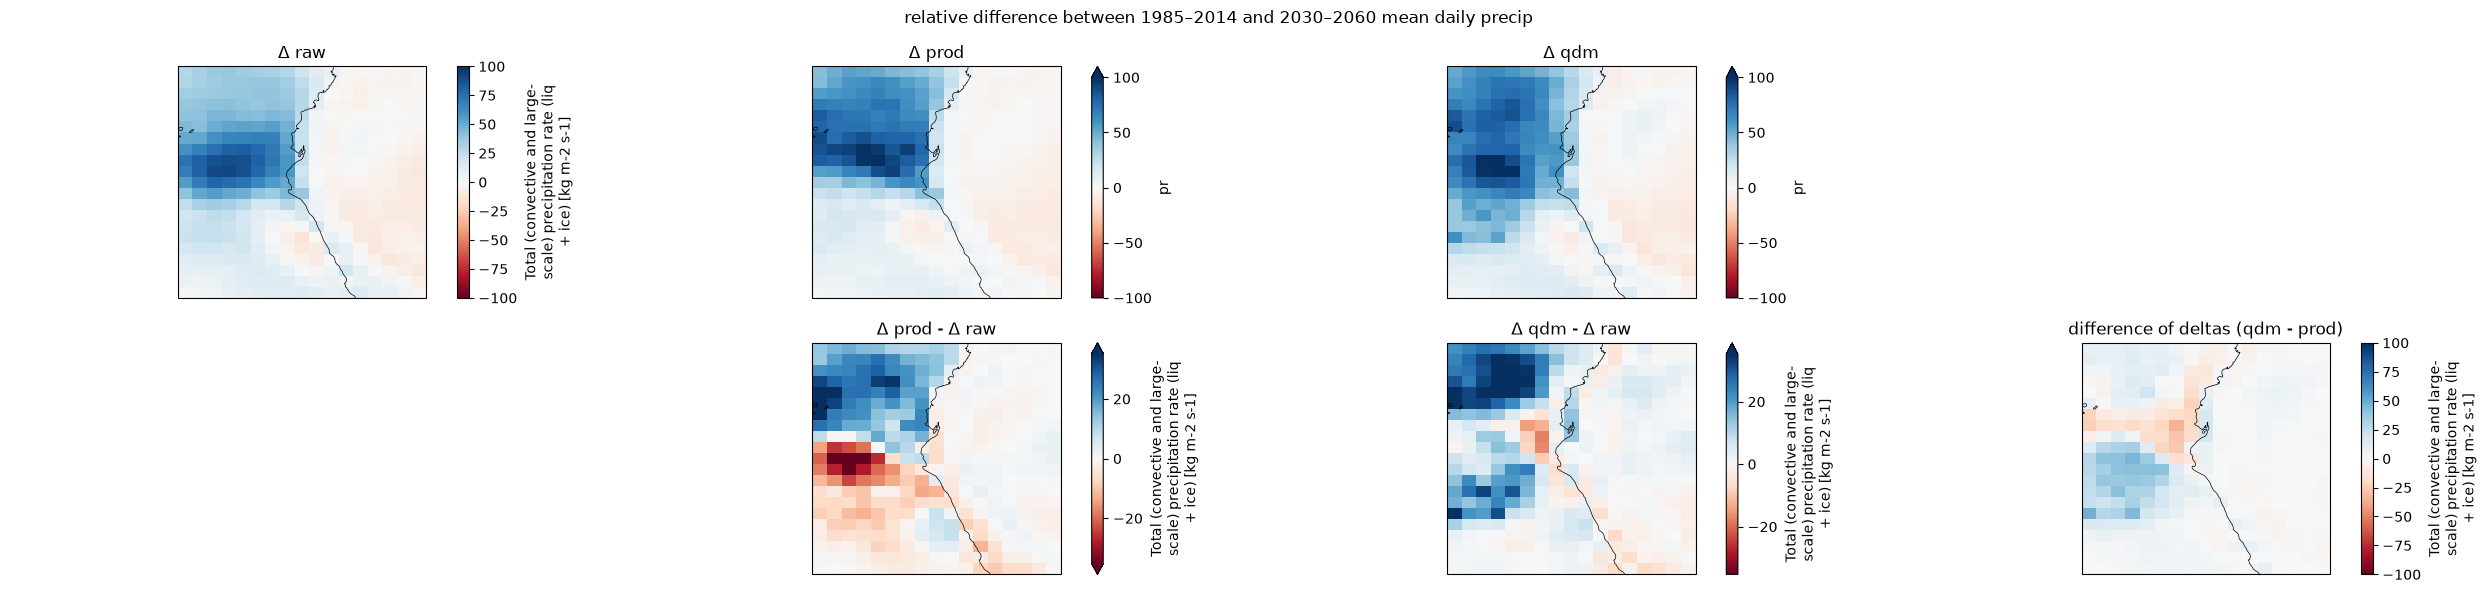

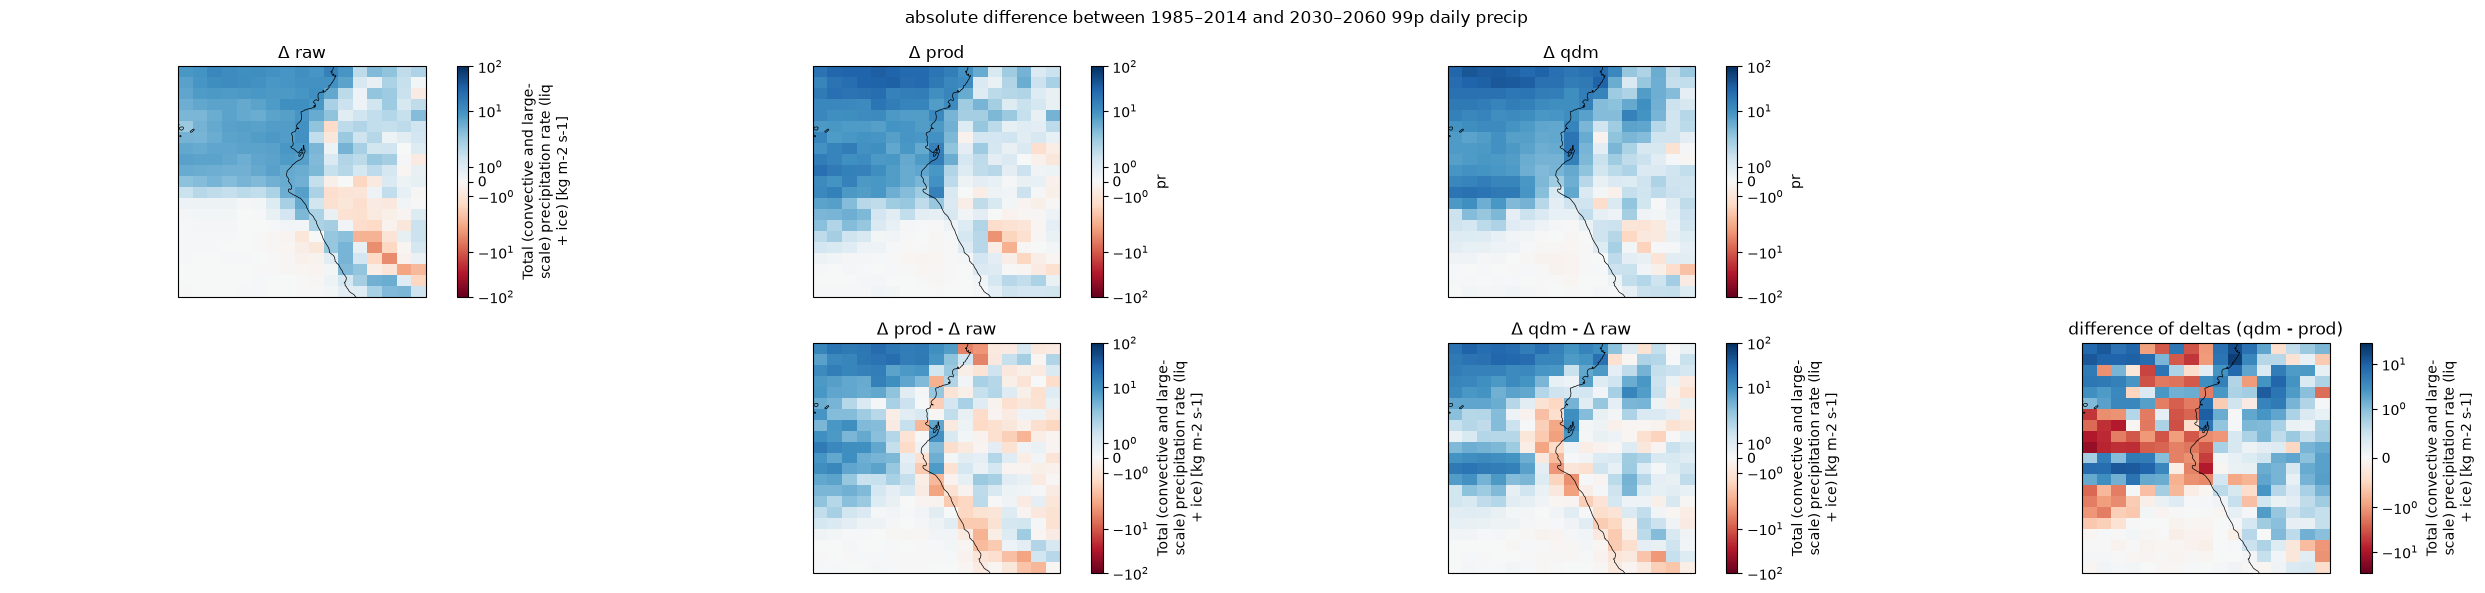

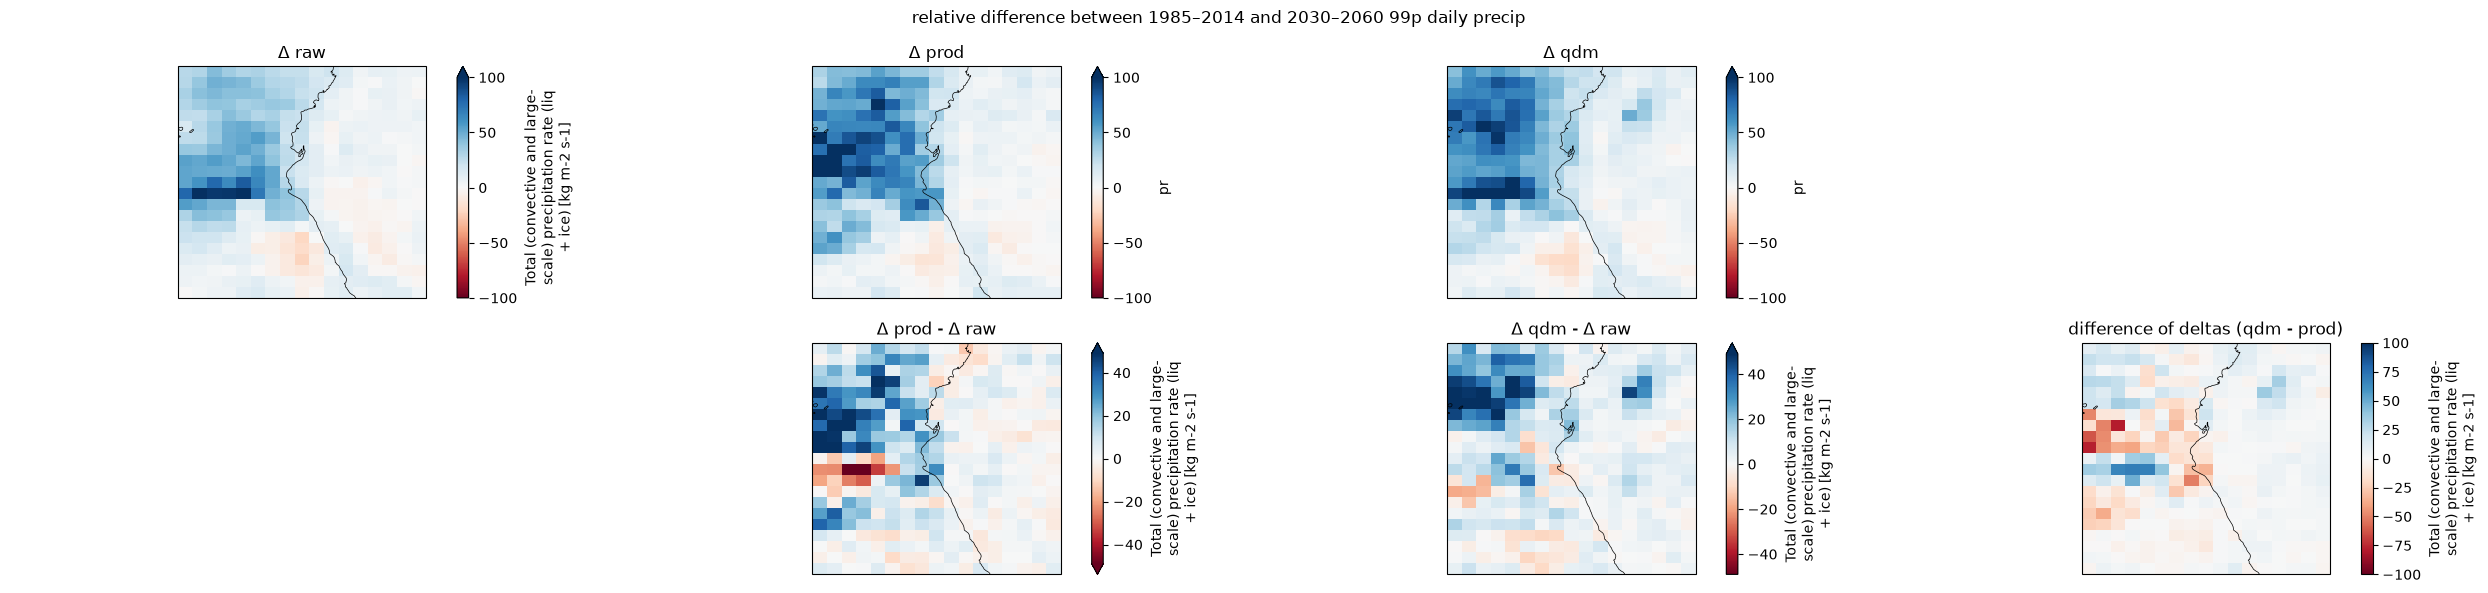

In [60]:
from matplotlib.colors import SymLogNorm

# Coastlines via the _HAS_CARTOPY / cfeature.COASTLINE pattern already used by
# _plot_map / plot_time_extremes above.
_proj_kw = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
_transform_kw = dict(transform=ccrs.PlateCarree()) if _HAS_CARTOPY else {}

# The two middle panels on row 2 are directly compared against each other
# (how much each method's climate-change delta differs from the raw GCM's),
# so they need one shared colorbar per figure — otherwise a difference in
# scale alone could be mistaken for a difference in magnitude.
_RESIDUAL_TITLES = ("Δ prod - Δ raw", "Δ qdm - Δ raw")


def _shared_robust_center0_limits(*das):
    """Symmetric-around-zero robust (2nd/98th percentile) limits pooled across arrays.

    Mirrors what xarray's robust=True, center=0 computes for a single panel,
    but pooled across all given arrays so callers can share one colorbar.
    """
    combined = np.concatenate([np.asarray(da.values).ravel() for da in das])
    combined = combined[np.isfinite(combined)]
    p2, p98 = np.nanpercentile(combined, [2, 98])
    vlim = max(abs(p2), abs(p98))
    return -vlim, vlim


for metric in ['mean', '99p']:
    for method in ['absolute', 'relative']:
        fig, axes = plt.subplots(2, 4, figsize=(26,6), subplot_kw=_proj_kw)

        # Shared limits for the two residual panels, recomputed per (metric,
        # method) so the range still varies figure to figure — just not
        # between the two panels within one figure. Uses var_lims_dict's
        # values when set (both residual titles already agree there for
        # 'absolute'); otherwise falls back to a pooled robust range instead
        # of each panel picking its own independently.
        residual_lims = {
            t: var_lims_dict[method][metric][t]
            for t in _RESIDUAL_TITLES
            if t in var_lims_dict[method][metric]
        }
        if len(residual_lims) < len(_RESIDUAL_TITLES):
            shared_vmin, shared_vmax = _shared_robust_center0_limits(
                *(plot_dict[method][metric][t][0] for t in _RESIDUAL_TITLES)
            )
            for t in _RESIDUAL_TITLES:
                residual_lims.setdefault(t, (shared_vmin, shared_vmax))

        for title, [da, (i, j)] in plot_dict[method][metric].items():
            lims = residual_lims[title] if title in _RESIDUAL_TITLES else var_lims_dict[method][metric].get(title)
            if lims is not None:
                vmin, vmax = lims
                if method == 'absolute':
                    # SymLogNorm: log-scaled beyond ±linthresh, linear within it —
                    # diverging deltas straddle zero, so a plain LogNorm can't be
                    # used, and a linear vmin/vmax washes near-zero values out.
                    norm = SymLogNorm(linthresh=vmax / 30, vmin=vmin, vmax=vmax)
                    da.plot(ax=axes[i, j], norm=norm, cmap='RdBu', **_transform_kw)
                else:
                    da.plot(ax=axes[i, j], vmin=vmin, vmax=vmax, cmap='RdBu', **_transform_kw)
            else:
                # remaining "relative" panels aren't in var_lims_dict (their
                # magnitude is much smaller than the raw delta panels) — let
                # robust=True pick a scale instead of washing them out.
                da.plot(ax=axes[i, j], robust=True, cmap='RdBu', center=0, **_transform_kw)
            if _HAS_CARTOPY:
                axes[i, j].add_feature(cfeature.COASTLINE, linewidth=0.5)
            axes[i, j].set_title(title)
            axes[i, j].set_xlabel(None)
            axes[i, j].set_ylabel(None)
        axes[1, 0].set_axis_off()
        axes[0, 3].set_axis_off()
        fig.suptitle(f"{method} difference between {HISTORICAL_PERIOD.start}–{HISTORICAL_PERIOD.stop} and {FUTURE_PERIOD.start}–{FUTURE_PERIOD.stop} {metric} daily precip")
        plt.tight_layout()
        plt.show()

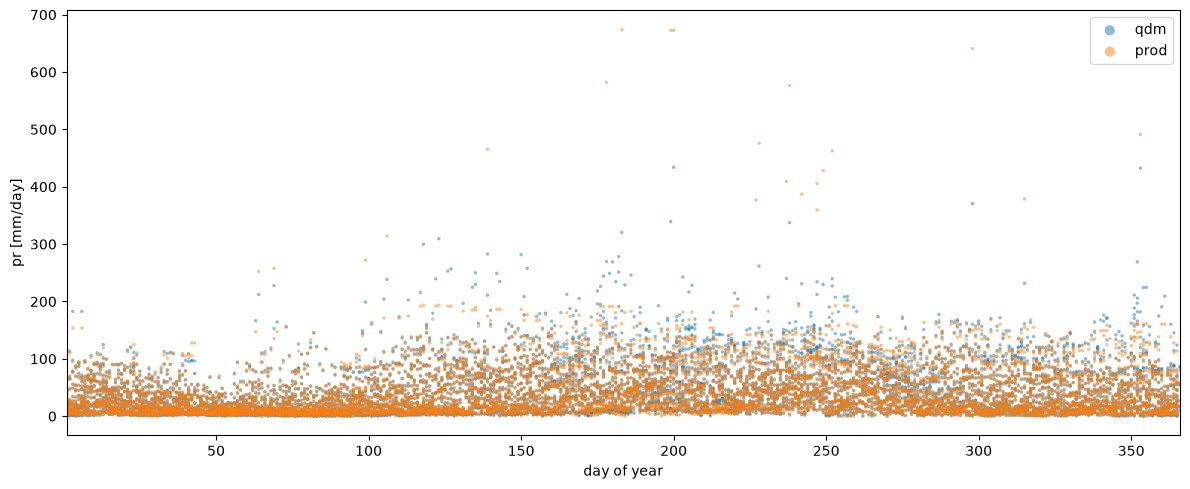

In [59]:
# ── Per-pixel scatter: nonparametric (orange) vs prod_debiased_coarse (blue) ──
FOCUS_LAT, FOCUS_LON = 3.5, -77.3
pt_qdm = ds_dict['qdm'].sel(lat=FOCUS_LAT, lon=FOCUS_LON, method="nearest").sel(time=FUTURE_PERIOD).pr.compute() * 86400
pt_prod = ds_dict['prod'].sel(lat=FOCUS_LAT, lon=FOCUS_LON, method="nearest").sel(time=FUTURE_PERIOD).compute() * 86400

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(
    pt_qdm["time"].dt.dayofyear,
    pt_qdm.values,
    c="tab:blue",
    s=6,
    alpha=0.5,
    edgecolors="none",
    label="qdm",
)
ax.scatter(
    pt_prod["time"].dt.dayofyear,
    pt_prod.values,
    c="tab:orange",
    s=6,
    alpha=0.5,
    edgecolors="none",
    label="prod",
)
ax.set_xlim(1, 366)
ax.set_xlabel("day of year")
ax.set_ylabel("pr [mm/day]")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [73]:
for comparison in plot_dict['absolute']['99p'].keys():
    print(f'{comparison} {plot_dict['absolute']['99p'][comparison][0].sel(lat=FOCUS_LAT, lon=FOCUS_LON, method='nearest').values}')

Δ raw 8.063912811279266
Δ prod 11.205884094237177
Δ qdm 25.98793304443359
Δ prod - Δ raw 3.141971282957911
Δ qdm - Δ raw 17.924020233154323
difference of deltas (qdm - prod) 14.782048950196412


In [79]:
for comparison in plot_dict['relative']['99p'].keys():
    print(f'{comparison} {plot_dict['relative']['99p'][comparison][0].sel(lat=FOCUS_LAT, lon=FOCUS_LON, method='nearest').values}')

Δ raw 12.132579656393103
Δ prod 7.522824462693108
Δ qdm 17.334304954163144
Δ prod - Δ raw -4.609755193699995
Δ qdm - Δ raw 5.201725297770041
difference of deltas (qdm - prod) 9.811480491470036


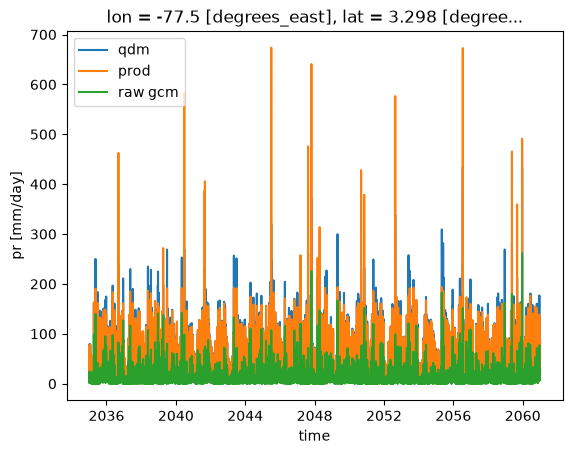

In [77]:
pt_raw = raw.sel(lat=FOCUS_LAT, lon=FOCUS_LON, method="nearest").sel(time=FUTURE_PERIOD).compute()
pt_qdm.plot(label='qdm')
pt_prod.plot(label='prod')
pt_raw.plot(label='raw gcm')
plt.ylabel("pr [mm/day]")

plt.legend()

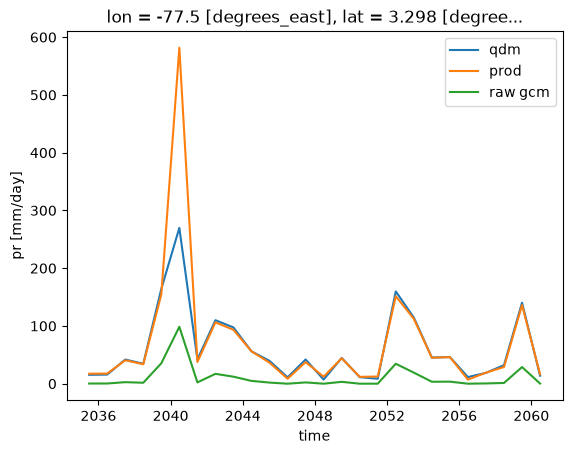

In [58]:
pt_raw = raw.sel(lat=FOCUS_LAT, lon=FOCUS_LON, method="nearest").sel(time=FUTURE_PERIOD).compute()
pt_qdm.sel(time=pt_qdm.time.dt.dayofyear == 178).plot(label='qdm')
pt_prod.sel(time=pt_qdm.time.dt.dayofyear == 178).plot(label='prod')
pt_raw.sel(time=pt_raw.time.dt.dayofyear == 178).plot(label='raw gcm')
plt.ylabel("pr [mm/day]")

plt.legend()